   Ranking                    District        State  Population  Growth  \
0        1                       Thane  Maharashtra    11060148   36.01   
1        2  North Twenty Four Parganas  West Bengal    10009781   12.04   
2        3                   Bangalore    Karnataka     9621551   47.18   
3        4                        Pune  Maharashtra     9429408   30.37   
4        5             Mumbai Suburban  Maharashtra     9356962    8.29   

   Sex-Ratio  Literacy  
0        886     84.53  
1        955     84.06  
2        916     87.67  
3        915     86.15  
4        860     89.91  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Ranking     610 non-null    int64  
 1   District    610 non-null    object 
 2   State       610 non-null    object 
 3   Population  610 non-null    int64  
 4   Growth      610 non-null    float64
 5   Sex

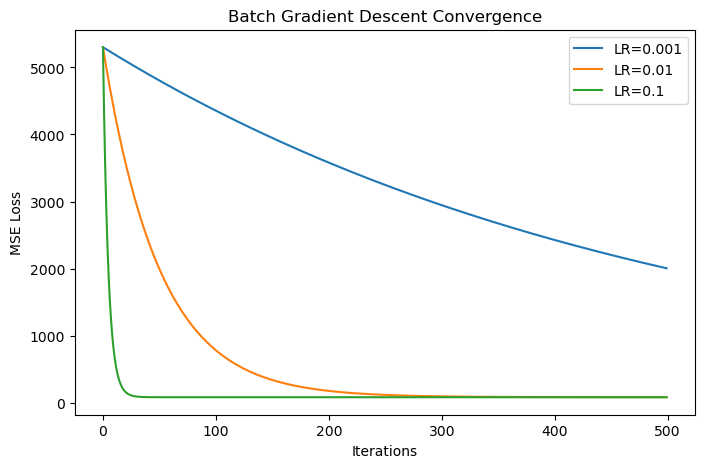

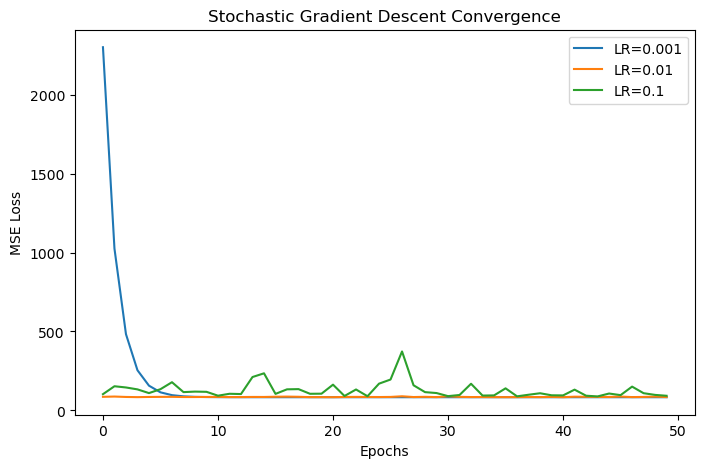


BGD Test Results:
MSE: 416.3495395778332
MAE 14.965130012367712
RMSE 20.404645049052757
R2: -1.8082453803301997


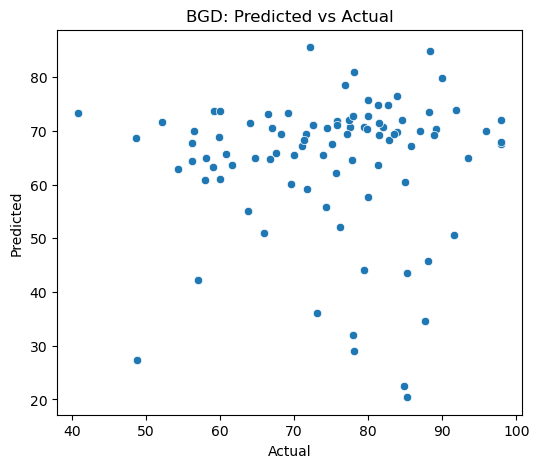

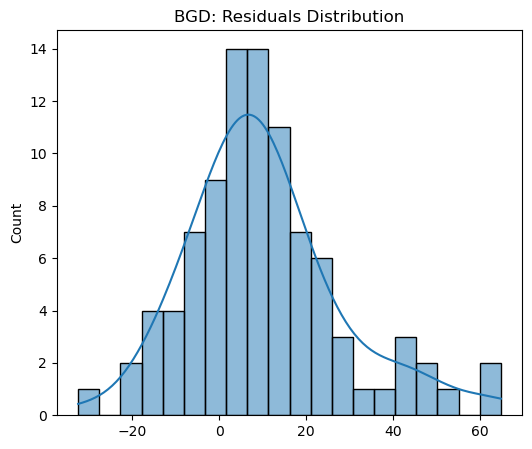


SGD Test Results:
MSE: 337.7623259122287
MAE 13.466206097386594
RMSE 18.37831129109061
R2: -1.2781807141047206


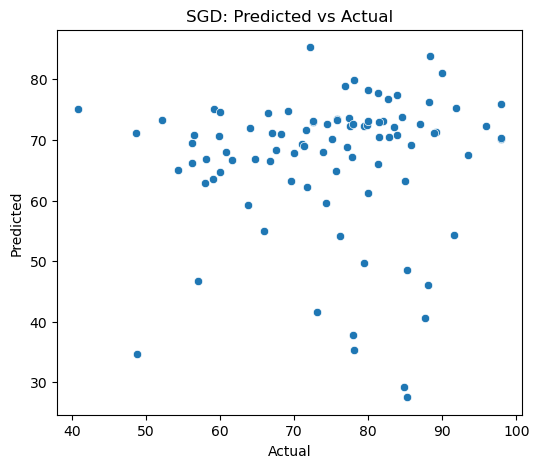

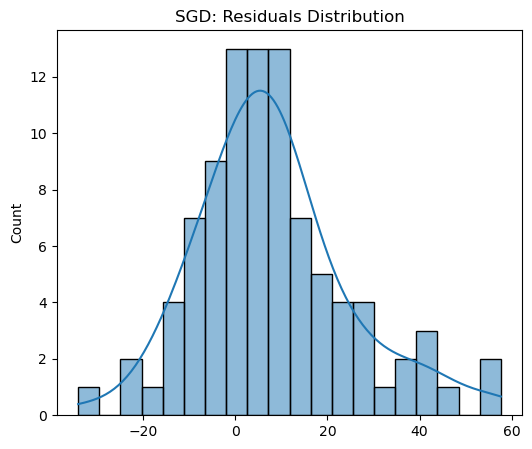

In [313]:
# ===============================================================
# INDIAN DISTRICTS LITERACY ANALYSIS
# Task 1: Linear Regression (Batch & Stochastic GD)
# Task 2: KNN Classification
# Author: Gauri Samant
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# ===============================================================
# DATA LOADING
# ===============================================================

df = pd.read_csv("census2011.csv")
df['Population'] = df['Population'].str.replace(',', '').astype(int)
df['Growth'] = df['Growth'].str.replace(' %', '').astype(float)
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

features = ['Population', 'Growth', 'Sex-Ratio']
target = 'Literacy'

X = df[features].values
y = df[target].values

# Split data into train (70%), validation (15%), test (15%)

n = len(X)
print(n)
train_end = int(0.7 * n)
print(train_end)
val_end = int(0.85 * n)
print(val_end)

X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]

# Normalize data

mean = X_train.mean(axis=0)
print("Mean",mean)
std = X_train.std(axis=0)
print("Std",std)

X_train = (X_train - mean) / std
#print("Training",x_train)
X_val = (X_val - mean) / std
#print("Validation",x_val)
X_test = (X_test - mean) / std
#print("Testing",x_test)

# ===============================================================
# Task 1: LINEAR REGRESSION
# ===============================================================

def predict(X, weights):
    return np.dot(X, weights)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_val_b = np.c_[np.ones((X_val.shape[0], 1)), X_val]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# ---------------------------
# Batch Gradient Descent
# ---------------------------
def batch_gradient_descent(X, y, lr=0.01, epochs=1000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    losses = []

    for epoch in range(epochs):
        y_pred = predict(X, weights)
        error = y_pred - y
        grad = (1 / n_samples) * np.dot(X.T, error)
        weights -= lr * grad

        losses.append(mse(y, y_pred))

    return weights, losses

lrs = [0.001, 0.01, 0.1]
bgd_results = {}

for lr in lrs:
    w, losses = batch_gradient_descent(X_train_b, y_train, lr, 500)
    bgd_results[lr] = (w, losses)

# Plot BGD convergence
plt.figure(figsize=(8,5))
for lr, (w, losses) in bgd_results.items():
    plt.plot(losses, label=f'LR={lr}')
plt.xlabel('Iterations')
plt.ylabel('MSE Loss')
plt.title('Batch Gradient Descent Convergence')
plt.legend()
plt.show()

# ---------------------------
# Stochastic Gradient Descent
# ---------------------------

def stochastic_gradient_descent(X, y, lr=0.01, epochs=50):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    losses = []

    for epoch in range(epochs):
        indices = np.random.permutation(n_samples)
        X_shuffled, y_shuffled = X[indices], y[indices]

        for i in range(n_samples):
            xi = X_shuffled[i, :].reshape(1, -1)
            yi = y_shuffled[i]
            y_pred = predict(xi, weights)
            grad = np.dot(xi.T, (y_pred - yi))
            weights -= lr * grad.flatten()

        # Record loss per epoch
        losses.append(mse(y, predict(X, weights)))

    return weights, losses

sgd_results = {}
for lr in lrs:
    w, losses = stochastic_gradient_descent(X_train_b, y_train, lr, 50)
    sgd_results[lr] = (w, losses)

# Plot SGD convergence
plt.figure(figsize=(8,5))
for lr, (w, losses) in sgd_results.items():
    plt.plot(losses, label=f'LR={lr}')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Stochastic Gradient Descent Convergence')
plt.legend()
plt.show()

# Pick best learning rate (say 0.01)
bgd_w = bgd_results[0.01][0]
sgd_w = sgd_results[0.01][0]

for name, w in [('BGD', bgd_w), ('SGD', sgd_w)]:
    y_pred = predict(X_test_b, w)
    print(f"\n{name} Test Results:")
    print("MSE:", mse(y_test, y_pred))
    #=============================================================
    print("MAE",mae(y_test,y_pred))
    print("RMSE",rmse(y_test,y_pred))
    #==========================================================      
    
    print("R2:", r2_score(y_test, y_pred))

    # Scatter: Predicted vs Actual
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{name}: Predicted vs Actual")
    plt.show()

    # Residuals
    residuals = y_test - y_pred
    plt.figure(figsize=(6,5))
    sns.histplot(residuals, bins=20, kde=True)
    plt.title(f"{name}: Residuals Distribution")
    plt.show()

Data Overview:
   Ranking                    District        State  Population  Growth  \
0        1                       Thane  Maharashtra    11060148   36.01   
1        2  North Twenty Four Parganas  West Bengal    10009781   12.04   
2        3                   Bangalore    Karnataka     9621551   47.18   
3        4                        Pune  Maharashtra     9429408   30.37   
4        5             Mumbai Suburban  Maharashtra     9356962    8.29   

   Sex-Ratio  Literacy  
0        886     84.53  
1        955     84.06  
2        916     87.67  
3        915     86.15  
4        860     89.91  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Ranking     610 non-null    int64  
 1   District    610 non-null    object 
 2   State       610 non-null    object 
 3   Population  610 non-null    int64  
 4   Growth      61

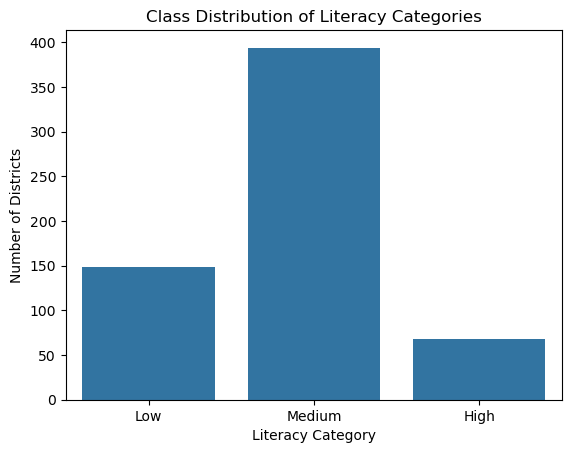


--- Evaluating for k = 3 ---
Accuracy (k=3): 0.489
Predicted  High  Low  Medium
Actual                      
Low           2    0      17
Medium        6   12      42
High          3    2       8 



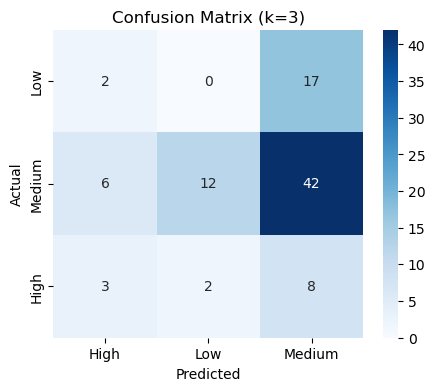


--- Evaluating for k = 5 ---
Accuracy (k=5): 0.446
Predicted  High  Low  Medium
Actual                      
Low           1    1      17
Medium        7   13      40
High          0    0      13 



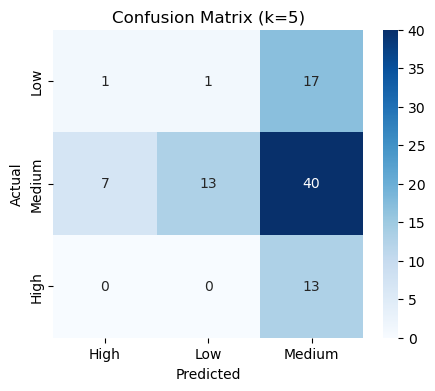


--- Evaluating for k = 7 ---
Accuracy (k=7): 0.478
Predicted  High  Low  Medium
Actual                      
Low           0    0      19
Medium        1   15      44
High          0    0      13 



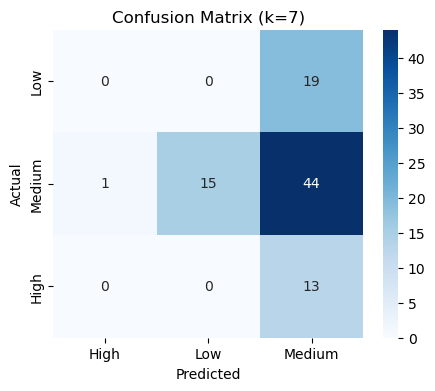

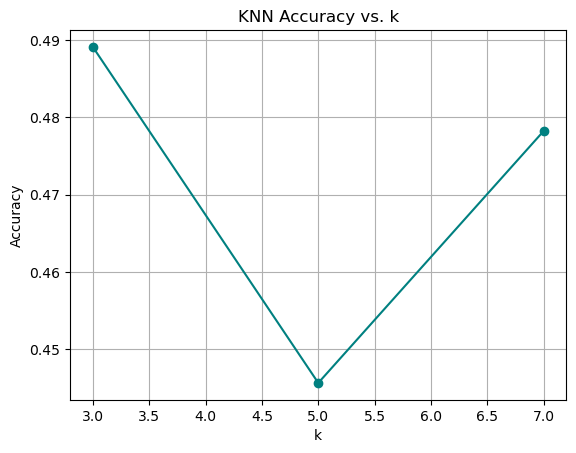

Cross-validation mean accuracy (k=3): 0.493
Cross-validation mean accuracy (k=5): 0.528
Cross-validation mean accuracy (k=7): 0.559


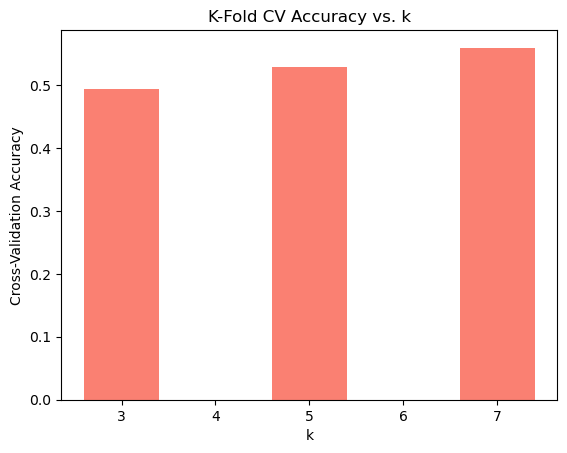


Best performing k based on test set: 3
KNN implementation and evaluation completed successfully.


In [311]:
# -------------------------------------------------------------
# TASK 2: KNN CLASSIFIER
# Dataset: Indian Districts Population Data
# Author: Gauri Samant
# -------------------------------------------------------------

# Allowed Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# 1. DATA LOADING AND EXPLORATION
# -------------------------------------------------------------

# Load dataset (make sure the CSV file is in the same folder)
df = pd.read_csv("census2011.csv")

df['Population'] = df['Population'].str.replace(',', '').astype(int)
df['Growth'] = df['Growth'].str.replace(' %', '').astype(float)

print("Data Overview:")
print(df.head())
print("\nDataset Info:")
print(df.info())

# -------------------------------------------------------------
# 2. DATA CLEANING & FEATURE SELECTION
# -------------------------------------------------------------
# Drop rows with missing literacy values
df = df.dropna(subset=['Literacy'])

# Create Literacy Category labels
df['Literacy_Category'] = pd.cut(
    df['Literacy'],
    bins=[0, 65, 85, 100],
    labels=['Low', 'Medium', 'High']
)

# Select numeric features for KNN
features = ['Population', 'Growth', 'Sex-Ratio']
X = df[features].values
y = df['Literacy_Category'].values

# Check class distribution
sns.countplot(x='Literacy_Category', data=df)
plt.title("Class Distribution of Literacy Categories")
plt.xlabel("Literacy Category")
plt.ylabel("Number of Districts")
plt.show()

# -------------------------------------------------------------
# 3. TRAIN-TEST SPLIT (85%-15%)
# -------------------------------------------------------------
np.random.seed(42)
indices = np.arange(len(X))
np.random.shuffle(indices)

split = int(0.85 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# -------------------------------------------------------------
# 4. KNN IMPLEMENTATION FROM SCRATCH
# -------------------------------------------------------------

def euclidean_distance(a, b):
    """Compute Euclidean distance between two vectors."""
    return np.sqrt(np.sum((a - b) ** 2))

def knn_predict(X_train, y_train, x_test, k=3):
    """Predict the class of a single sample using KNN."""
    distances = [euclidean_distance(x_test, x_train) for x_train in X_train]
    k_indices = np.argsort(distances)[:k]
    k_neighbors = y_train[k_indices]
    values, counts = np.unique(k_neighbors, return_counts=True)
    return values[np.argmax(counts)]

def knn_predict_batch(X_train, y_train, X_test, k=3):
    """Predict the classes for all samples in the test set."""
    return np.array([knn_predict(X_train, y_train, x, k) for x in X_test])

# -------------------------------------------------------------
# 5. EVALUATION FUNCTIONS
# -------------------------------------------------------------
def confusion_matrix(y_true, y_pred, labels=['Low', 'Medium', 'High']):
    """Build a confusion matrix using pandas crosstab."""
    matrix = pd.crosstab(
        pd.Series(y_true, name='Actual'),
        pd.Series(y_pred, name='Predicted'),
        rownames=['Actual'], colnames=['Predicted']
    )
    return matrix

def accuracy(y_true, y_pred):
    """Compute simple classification accuracy."""
    return np.mean(y_true == y_pred)

# -------------------------------------------------------------
# 6. MODEL EVALUATION FOR DIFFERENT K VALUES
# -------------------------------------------------------------
results = []

for k in [3, 5, 7]:
    print(f"\n--- Evaluating for k = {k} ---")
    y_pred = knn_predict_batch(X_train, y_train, X_test, k)
    acc = accuracy(y_test, y_pred)
    results.append(acc)

    cm = confusion_matrix(y_test, y_pred)
    print(f"Accuracy (k={k}): {acc:.3f}")
    print(cm, "\n")

    # Plot confusion matrix heatmap
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix (k={k})")
    plt.show()

# Accuracy comparison plot
plt.figure()
plt.plot([3,5,7], results, marker='o', color='teal')
plt.title("KNN Accuracy vs. k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# -------------------------------------------------------------
# 7. MANUAL K-FOLD CROSS VALIDATION
# -------------------------------------------------------------
def k_fold_cv(X, y, k_neighbors=3, folds=5):
    """Perform manual k-fold cross validation (no sklearn)."""
    fold_size = len(X) // folds
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    accuracies = []

    for i in range(folds):
        start, end = i * fold_size, (i + 1) * fold_size
        val_idx = indices[start:end]
        train_idx = np.concatenate((indices[:start], indices[end:]))

        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]

        y_pred_fold = knn_predict_batch(X_train_fold, y_train_fold, X_val_fold, k_neighbors)
        accuracies.append(accuracy(y_val_fold, y_pred_fold))

    return np.mean(accuracies)

# Perform 5-fold cross validation for each k
cv_results = {}
for k in [3, 5, 7]:
    cv_acc = k_fold_cv(X_train, y_train, k_neighbors=k, folds=5)
    cv_results[k] = cv_acc
    print(f"Cross-validation mean accuracy (k={k}): {cv_acc:.3f}")

# Plot CV accuracy
plt.figure()
plt.bar(cv_results.keys(), cv_results.values(), color='salmon')
plt.title("K-Fold CV Accuracy vs. k")
plt.xlabel("k")
plt.ylabel("Cross-Validation Accuracy")
plt.show()

# -------------------------------------------------------------
# 8. CONCLUSION
# -------------------------------------------------------------
best_k = [3,5,7][np.argmax(results)]
print(f"\nBest performing k based on test set: {best_k}")
print("KNN implementation and evaluation completed successfully.")